In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests
import io
import pandas as pd

In [5]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
response = requests.get(URL)
response.raise_for_status()
csv_content = io.StringIO(response.text)

In [6]:
df = pd.read_csv(csv_content)
print('Data downloaded and read into a dataframe!')
print(df.head())
df.describe()
df.columns

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [8]:
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
    #create figure
plt.figure(figsize=(10, 6))
df_line.plot(kind = 'line')

<Axes: xlabel='Year'>

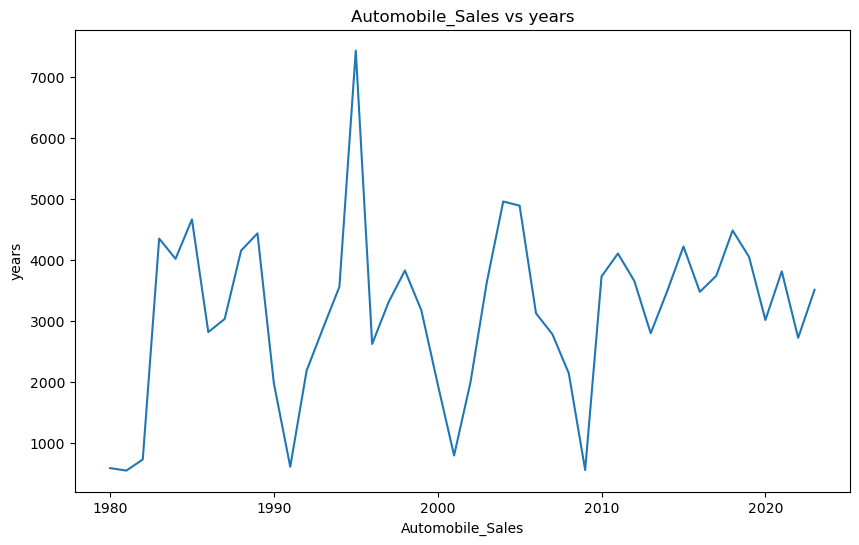

In [9]:
plt.xlabel('Automobile_Sales')
plt.ylabel('years')
plt.title('Automobile_Sales vs years')
plt.show()

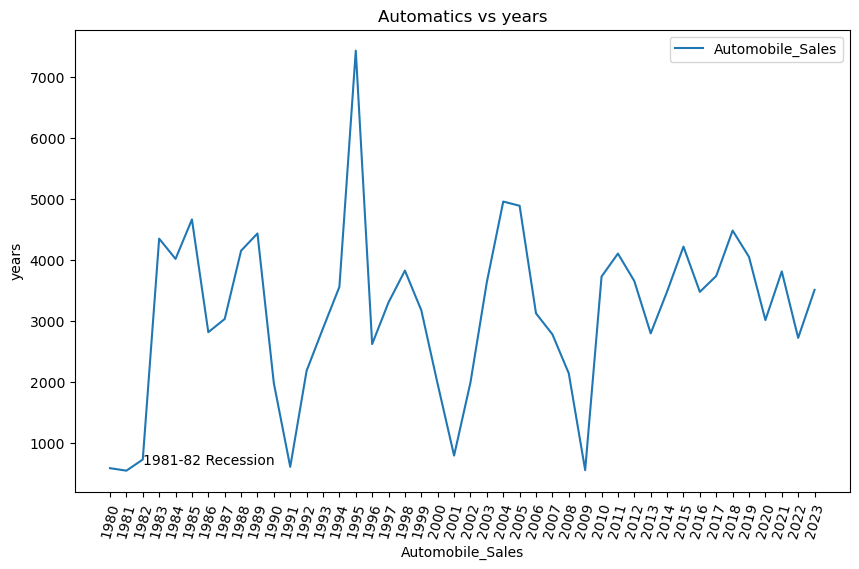

In [11]:
  plt.figure(figsize=(10, 6))
  df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()
  df_line.plot(kind = 'line')
  plt.xticks(list(range(1980,2024)), rotation = 75)
  plt.xlabel('Automobile_Sales')
  plt.ylabel('years')
  plt.title('Automatics vs years')
  plt.text(1982, 650, '1981-82 Recession')
  plt.legend()
  plt.show()

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

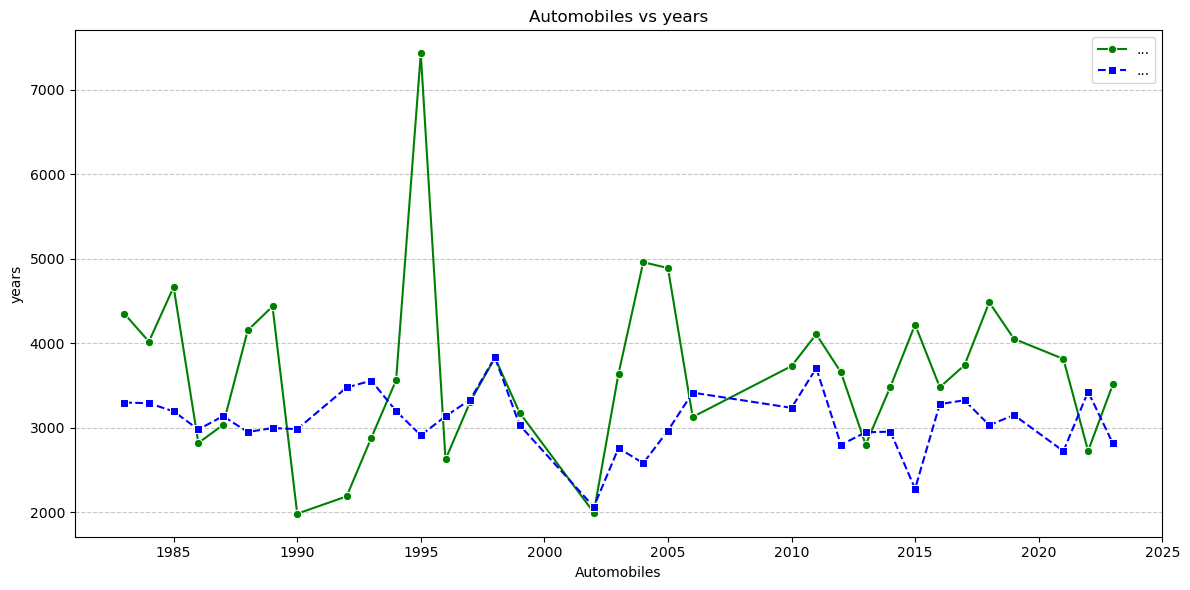

In [16]:
df_non_rec = df[df['Recession'] == 0]

df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o', linestyle='-', color='green', label='...')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend', marker='s', linestyle='--', color='blue', label='...')

# Add labels, legend, title, and grid
plt.xlabel('Automobiles')
plt.ylabel('years')
plt.title('Automobiles vs years')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

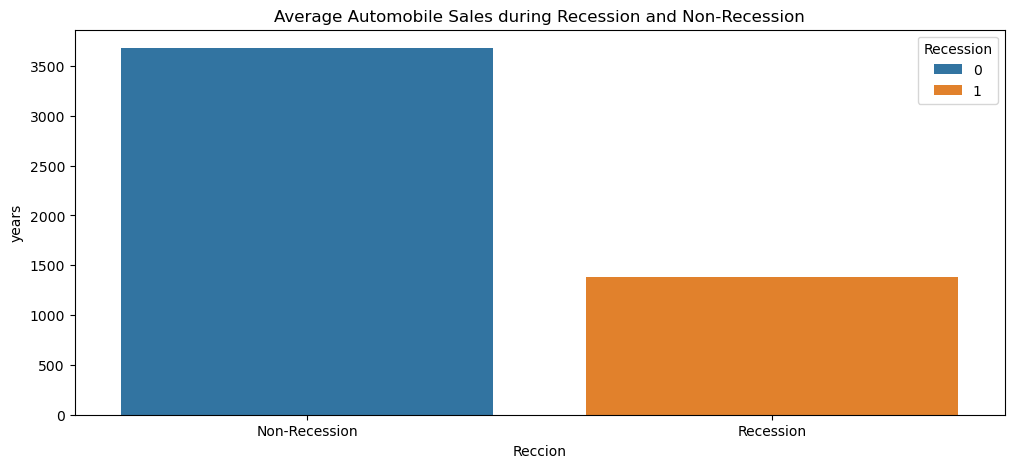

In [17]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(12,5))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel('Reccion')
plt.ylabel('years')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

In [18]:
grouped_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Automobile_Sales')
plt.ylabel('Year')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.